# VQLS Limitations without Noise: Conditioning, Cost Functions, and Ansatz Depth

In this notebook, we study limitations of the Variational Quantum Linear Solver (VQLS) in an ideal noiseless setting.

The goal is not to solve a physically complicated system, but to isolate how VQLS performance depends on:

1. the condition number of the matrix,
2. the choice of cost function,
3. the ansatz depth,
4. the optimizer behavior,
5. and the number of Pauli terms required to evaluate the cost.

This provides a controlled benchmark for understanding VQLS before applying it to time-dependent differential equations.

## Case I: Controlled Linear System with Tunable Condition Number

We consider a simple four-dimensional linear system

$$
Ax=b,
$$

where

$$
A=\text{diag}\left(1,1,1,\frac{1}{\kappa}\right),
$$

and

$$
b=\frac{1}{\sqrt{2}}
\begin{pmatrix}
1\\
0\\
0\\
1
\end{pmatrix}.
$$

The parameter $(\kappa)$ controls the condition number of the matrix. Larger $\kappa$ corresponds to a more ill-conditioned system.

If we used this diagonal matrix directly, the problem would be too simple. Therefore, we rotate the matrix using a unitary transformation,

$$
A' = U^\dagger A U.
$$

This preserves the spectrum and condition number of $A$, but makes the matrix non-diagonal in the computational basis. In this notebook, we use

$$
U = H_0\,\text{CNOT}_{0,1},
$$

where $H_0$ is a Hadamard gate acting on qubit 0.

This setup allows us to study the effect of conditioning while keeping the system size fixed at two qubits.

## Imports

We import the required numerical and quantum-computing tools. Qiskit is used to construct the ansatz, convert matrices to Pauli operators, and evaluate expectation values. SciPy is used for the classical optimizer. 

In [4]:
#Importing necessary packages and functions
from qiskit import QuantumCircuit,transpile
import numpy as np
from qiskit.quantum_info import SparsePauliOp, DensityMatrix, Statevector
from qiskit.circuit.library import TwoLocal,n_local
from scipy.optimize import minimize
from qiskit_aer.primitives import EstimatorV2
from qiskit.quantum_info import Operator
from qiskit_aer import AerSimulator


In [5]:
import time
import datetime
import pickle
import os
import matplotlib.pyplot as plt
import pandas as pd

## Matrix Construction

The functions below construct the test matrix, define the unitary rotation, and form the rotated matrix $A'=U^\dagger A U$.

The rotation is useful because it keeps the eigenvalues and condition number fixed while making the linear system less trivial in the computational basis.

The right-hand side vector is chosen to be a Bell-like two-qubit state,

$$
|b\rangle = \frac{1}{\sqrt{2}}(1,0,0,1)^T.
$$

This gives a normalized vector that can be directly interpreted as a quantum state.

The classical solution is obtained using `np.linalg.solve` and then normalized. The normalized classical solution is used as the reference quantum state for computing fidelity.

In [6]:
#Setting up Case I and classical Solution
def CaseI_A_matrix(kappa):
    return np.diag([1.0, 1.0, 1.0, 1.0/float(kappa)])

#Creating different U matrices
def make_U(choice):
    qc = QuantumCircuit(2)
    if choice == "H0":
        qc.h(0)
    elif choice == "H1":
        qc.h(1)
    elif choice == "CNOT":
        qc.cx(0,1)
    elif choice == "H0_CNOT":
        qc.h(0); qc.cx(0,1)
    elif choice == "H0H1_CNOT":
        qc.h(0); qc.h(1); qc.cx(0,1)
    return Operator(qc).data

#Creating a function to create rotated matrix, A'
def rotate_A(A, U):
    return U.conj().T @ A @ U

#Creating b vector: Bell state
def b_bell_4():
    b = np.array([1,0,0,1], dtype=float)
    return b/np.linalg.norm(b)

#Creating function to normalize a vector
def normalize(v):
    return v / np.linalg.norm(v)

#generating a classical solution 
def classical_solution(A, b):
    x = np.linalg.solve(A, b)
    return normalize(x)

In [7]:
#Generating pauli terms from an operator
def op_from_matrix(M):
    return SparsePauliOp.from_operator(M)

#Creating an identity pauli term, i.e II or III or ... 
def identity_op(n_qubits):
    return SparsePauliOp.from_list([("I"*n_qubits, 1.0)])

#defining dagger of an opertor
def A_dagger(A_op):
    return A_op.adjoint()

## VQLS Cost Functions

We compare three cost functions:

1. **Projector cost**
2. **Residual cost**
3. **Normalized cost**

The projector-based cost measures whether $A|x(\theta)\rangle$ is aligned with $|b\rangle$:

$$
C_{\rm proj}(\theta) =
\langle x(\theta)|
A^\dagger
\left(I-|b\rangle\langle b|\right)
A
|x(\theta)\rangle.
$$

This cost becomes small when $A|x(\theta)\rangle$ points in the direction of $|b\rangle$.

In [8]:
#Creating cost Hamiltonian matrix needed for Projector based cost function
def cost_hamiltonian(A_op, b_state):
    n_qubits = int(np.log2(len(b_state)))
    I = identity_op(n_qubits)
    B_dm = DensityMatrix(b_state)           # |b><b|
    B_op = SparsePauliOp.from_operator(B_dm)
    A_dag = A_dagger(A_op)
    H = A_dag @ (I - B_op) @ A_op
    # hermitianize & real-coeff cleanup
    H = 0.5*(H + H.adjoint())
    H = SparsePauliOp(H.paulis, coeffs=np.real(H.coeffs))
    return H

For the normalized cost, we use operators involving $A^2$ and $A|b\rangle\langle b|A$. The normalized cost compares the overlap direction after accounting for the norm of $A|x\rangle$:

$$
C_{\rm norm}(\theta)=
1-
\frac{
\langle x(\theta)|A^\dagger |b\rangle\langle b| A|x(\theta)\rangle
}{
\langle x(\theta)|A^\dagger A|x(\theta)\rangle
}.
$$

This cost is less sensitive to the overall scaling of $A|x\rangle$.

In [9]:
#Creating a |b><b| operator 
def projector_op_from_state(b_state):
    B_dm = DensityMatrix(b_state)
    return SparsePauliOp.from_operator(B_dm)

#Creating a function to make operator real
def hermitian_real_op(op):
    op = 0.5 * (op + op.adjoint())
    return SparsePauliOp(op.paulis, coeffs=np.real(op.coeffs))

#Creating operators needed for defining Normalized cost function
def normalized_cost_operators(A_op, b_state):
    B_op = projector_op_from_state(b_state)

    A2_op = A_op @ A_op
    A2_op = hermitian_real_op(A2_op)

    ABA_op = A_op @ B_op @ A_op
    ABA_op = hermitian_real_op(ABA_op)

    return A2_op, ABA_op

The residual cost directly computes

$$
C_{\rm res}(\theta)=\|A|x(\theta)\rangle-|b\rangle\|^2.
$$

In this statevector simulation, this can be computed directly. On real hardware, however, estimating this cost may require additional measurement strategies.

In [10]:
#Generating residual cost function
def residual_cost_from_state(A_mat, b, x_state):
    Ax = A_mat @ x_state
    return float(np.linalg.norm(Ax - b)**2)

## Ansatz and Diagnostics

The variational state $|x(\theta)\rangle$ is prepared using an $n$-local ansatz with $R_y$ rotations and linear CNOT entanglement.

The ansatz depth is controlled by `reps`. Increasing `reps` can improve expressibility, but it also increases the number of variational parameters and can make the optimization problem harder.

In [11]:
#Creating ansatz (n-local circuit)
def make_ansatz(n_qubits,reps):
    return n_local(n_qubits, rotation_blocks="ry", entanglement_blocks="cx", entanglement="linear", reps=reps,insert_barriers = False)

We use fidelity to compare the VQLS output state with the normalized classical solution:

$$
F = |\langle x_{\rm true}|x_{\rm VQLS}\rangle|^2.
$$

A fidelity close to 1 means that the VQLS state is close to the classical normalized solution.

In [12]:
#Pauli Count
def pauli_term_count(op: SparsePauliOp):
    return len(op.paulis)

#Generating statevector from parameters from the solution
def state_from_params(ansatz, params):
    qc = QuantumCircuit(ansatz.num_qubits)
    qc.compose(ansatz.assign_parameters(params), inplace=True)
    return Statevector.from_instruction(qc).data

#Defining fidelity
def fidelity(x_true, x_pred):
    return np.abs(np.vdot(x_true, x_pred))**2

## VQLS Solver for Case I

The function below runs VQLS for a fixed condition number $\kappa$, ansatz depth `reps`, and cost-function choice.

The main steps are:

1. Construct $A=\text{diag}(1,1,1,1/\kappa)$.
2. Rotate it to obtain $A'=U^\dagger A U$.
3. Construct the right-hand side state $|b\rangle$.
4. Compute the classical reference solution.
5. Build the cost-function operators.
6. Optimize the ansatz parameters.
7. Compare the VQLS state with the classical solution.

We record several diagnostics:

- final cost,
- number of optimizer function evaluations,
- fidelity,
- Pauli-term counts,
- raw residual,
- scaled residual.

The raw residual is
$$
\|A|x\rangle-b\|.
$$

However, VQLS naturally returns a normalized quantum state. Since the physical linear-system solution may require an overall scale factor, we also compute a scaled residual:

$$
\min_\alpha \|\alpha A|x\rangle-b\|.
$$

The scaled residual is often a more meaningful diagnostic for VQLS because it accounts for the unknown normalization of the quantum state.

In [13]:
#Final Function

def run_vqls_CaseI(kappa, reps, cost_type="projector", optimizer="COBYLA", maxiter=300, seed=0):
    np.random.seed(seed)

    # Build A and b
    A = CaseI_A_matrix(kappa)
    U = make_U("H0_CNOT")
    A_mat = rotate_A(A, U)
    b = b_bell_4()
    b = normalize(b)
    x_true = classical_solution(A_mat, b)

    # Operators based on cost function type
    A_op = SparsePauliOp.from_operator(A_mat)

    H = None
    A2_op = None
    ABA_op = None

    if cost_type == "projector":
        H = cost_hamiltonian(A_op, b)

    elif cost_type == "normalized":
        A2_op, ABA_op = normalized_cost_operators(A_op, b)

    elif cost_type == "residual":
        pass

    else:
        raise ValueError(f"Unknown cost_type: {cost_type}")

    # Ansatz
    ansatz = make_ansatz(n_qubits=2, reps=reps)

    # Estimator only needed for projector/normalised cost functions
    estimator = EstimatorV2()

    def costfunc(params):
        if cost_type == "projector":
            job = estimator.run([(ansatz, H, params)])
            return float(job.result()[0].data.evs)

        elif cost_type == "residual":
            x_state = state_from_params(ansatz, params)
            x_state = normalize(x_state)
            return residual_cost_from_state(A_mat, b, x_state)

        elif cost_type == "normalized":
            job1 = estimator.run([(ansatz, A2_op, params)])
            ev_A2 = float(job1.result()[0].data.evs)

            job2 = estimator.run([(ansatz, ABA_op, params)])
            ev_ABA = float(job2.result()[0].data.evs)

            if abs(ev_A2) < 1e-14:
                return 1.0

            return float(np.real(1.0 - ev_ABA / ev_A2))

        else:
            raise ValueError(f"Unknown cost_type: {cost_type}")

    init = np.random.uniform(0, 2*np.pi, ansatz.num_parameters)

    res = minimize(costfunc, init, method=optimizer, options={"maxiter": maxiter, "tol": 1e-10})

    # Evaluate final state
    x_pred = state_from_params(ansatz, res.x)
    x_pred = normalize(x_pred)

    # To align global sign
    if np.real(np.vdot(x_true, x_pred)) < 0:
        x_pred = -x_pred

    #Raw residual & Scaled residual  
    Ax = A_mat @ x_pred
    raw_residual = np.linalg.norm(Ax - b)
    alpha = np.vdot(Ax, b) / np.vdot(Ax, Ax)
    scaled_residual = np.linalg.norm(alpha * Ax - b)

    return {
        "kappa": kappa,
        "reps": reps,
        "cost_type": cost_type,
        "optimizer": optimizer,
        "final_cost": res.fun,
        "iters": res.nfev,
        "fidelity": fidelity(x_true, x_pred),
        "A_terms": pauli_term_count(A_op),
        "H_terms": pauli_term_count(H) if H is not None else None,
        "A2_terms": pauli_term_count(A2_op) if A2_op is not None else None,
        "ABA_terms": pauli_term_count(ABA_op) if ABA_op is not None else None,
        "x_true": x_true,
        "x_pred": x_pred,
        "raw_residual": raw_residual,
        "scaled_residual": scaled_residual
    }

## Parameter Scan

We now scan over:

$$
\kappa \in \{1,3,10,30,100\},
$$

ansatz depths

$$
\text{reps} \in \{1,2,3\},
$$

and three cost functions:

$$
\text{projector},\quad \text{residual},\quad \text{normalized}.
$$

The goal is to study how conditioning, ansatz depth, and cost-function choice affect VQLS performance.

For each case, we record the final cost, fidelity, residuals, optimizer iterations, and the number of Pauli terms in the relevant cost operators.

In [14]:
#For different values of condition number (kappa), ansatz depth (reps) and cost function types

# file name
save_file = "results_vqls.pkl"

kappas = [1, 3, 10, 30, 100]
reps_list = [1, 2, 3]
cost_types = ["projector", "residual", "normalized"]

results = []

total_cases = len(cost_types) * len(kappas) * len(reps_list)
print(f"Total number of parameter cases: {total_cases}")

time_all = 0

for cost_type in cost_types:
    for reps in reps_list:
        for kappa in kappas:
            print(f"Running: cost_type={cost_type}, reps={reps}, kappa={kappa}")

            t0 = time.time()
            out = run_vqls_CaseI(kappa, reps=reps, cost_type=cost_type, maxiter=300, seed=1)
            t1 = time.time()
            # Add metadata
            out["runtime_sec"] = t1 - t0
            out["runtime_min"] = (t1 - t0) / 60
            out["timestamp"] = time.time()
            out["time_str"] = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
            
            results.append(out)
            
            print(f"Done in {out['runtime_sec']:.2f} sec")

            time_all = time_all + out["runtime_min"]

            # Save after each case
            with open(save_file, "wb") as f:
                pickle.dump(results, f)
            
print("All runs complete!")
print(f"Done in {time_all} min")


Total number of parameter cases: 45
Running: cost_type=projector, reps=1, kappa=1
Done in 1.76 sec
Running: cost_type=projector, reps=1, kappa=3
Done in 1.33 sec
Running: cost_type=projector, reps=1, kappa=10
Done in 2.34 sec
Running: cost_type=projector, reps=1, kappa=30
Done in 1.99 sec
Running: cost_type=projector, reps=1, kappa=100
Done in 1.96 sec
Running: cost_type=projector, reps=2, kappa=1
Done in 0.88 sec
Running: cost_type=projector, reps=2, kappa=3
Done in 1.24 sec
Running: cost_type=projector, reps=2, kappa=10
Done in 1.22 sec
Running: cost_type=projector, reps=2, kappa=30
Done in 1.06 sec
Running: cost_type=projector, reps=2, kappa=100
Done in 1.37 sec
Running: cost_type=projector, reps=3, kappa=1
Done in 1.07 sec
Running: cost_type=projector, reps=3, kappa=3
Done in 1.57 sec
Running: cost_type=projector, reps=3, kappa=10
Done in 1.71 sec
Running: cost_type=projector, reps=3, kappa=30
Done in 1.73 sec
Running: cost_type=projector, reps=3, kappa=100
Done in 1.84 sec
Running

## Comparison Plots 

We convert the list of result dictionaries into a Pandas DataFrame. This allows us to compare performance across condition numbers, ansatz depths, and cost-function choices.

In [15]:
# Load saved results
with open("results_vqls.pkl", "rb") as f:
    results = pickle.load(f)

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.DataFrame(results)

# Converting numpy scalar types to python floats and ints
for col in ["final_cost", "fidelity","raw_residual","scaled_residual"]:
    if col in df.columns:
        df[col] = df[col].astype(float)
for col in ["iters", "kappa", "reps"]:
    if col in df.columns:
        df[col] = df[col].astype(int)

# cost_type should be as string
if "cost_type" in df.columns:
    df["cost_type"] = df["cost_type"].astype(str)


The most important diagnostics are:

- **Fidelity:** closeness of the VQLS state to the normalized classical solution.
- **Final cost:** optimized value of the chosen cost function.
- **Iterations:** number of optimizer function evaluations.
- **Raw residual:** $\|A|x\rangle-b\|$.
- **Scaled residual:** residual after optimizing over an overall scale factor.
- **Pauli-term count:** approximate measurement complexity of the cost Hamiltonian.

## Pauli-Term Count

The number of Pauli terms gives a rough indication of the measurement complexity of the cost function. More Pauli terms generally mean that more expectation values must be estimated.

For the projector cost, the relevant operator is

$$
H=A(I-|b\rangle\langle b|)A.
$$

We count how many Pauli strings appear in this operator.

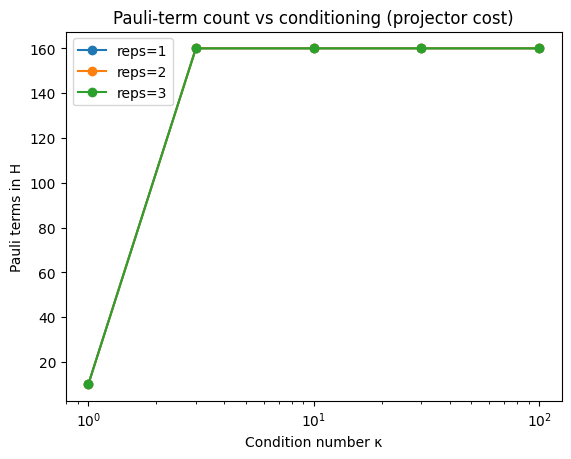

In [38]:
#Pauli terms (projector cost function)
df_proj = df[df["cost_type"] == "projector"].copy()

if not df_proj.empty:
    plt.figure()
    for reps, sub in df_proj.groupby("reps"):
        sub = sub.sort_values("kappa")
        plt.plot(sub["kappa"], sub["H_terms"], marker="o", label=f"reps={reps}")

    plt.xscale("log")
    plt.xlabel("Condition number κ")
    plt.ylabel("Pauli terms in H")
    plt.title("Pauli-term count vs conditioning (projector cost)")
    plt.legend()
    plt.show()

For $\kappa=1$, the matrix is proportional to the identity, so the Pauli decomposition is simple. For $\kappa>1$, the rotated matrix becomes nontrivial, and the number of Pauli terms increases.

For the normalized cost, the relevant operators are $A^2$ and $A|b\rangle\langle b|A$. We therefore
count the total number of Pauli terms appearing in these two operators.

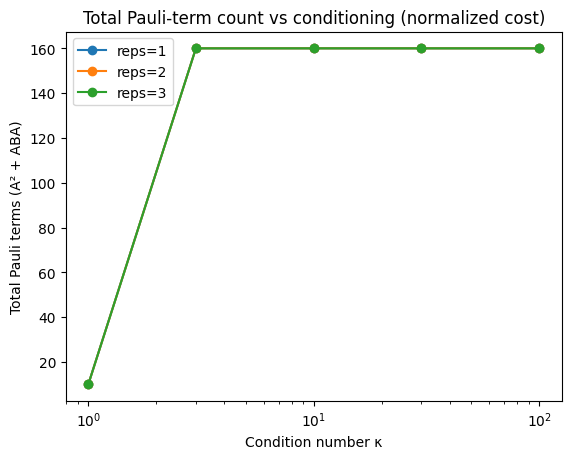

In [40]:
#Pauli terms (normalised cost function)
df_norm = df[df["cost_type"] == "normalized"].copy()

if not df_norm.empty:
    df_norm["norm_total_terms"] = df_norm["A2_terms"] + df_norm["ABA_terms"]

    plt.figure()
    for reps, sub in df_norm.groupby("reps"):
        sub = sub.sort_values("kappa")
        plt.plot(sub["kappa"], sub["norm_total_terms"], marker="o", label=f"reps={reps}")

    plt.xscale("log")
    plt.xlabel("Condition number κ")
    plt.ylabel("Total Pauli terms (A² + ABA)")
    plt.title("Total Pauli-term count vs conditioning (normalized cost)")
    plt.legend()
    plt.show()

The normalized cost has comparable Pauli-term complexity in this benchmark. In larger systems, however, the number of Pauli terms can grow substantially and become an important bottleneck.

## Metric Plots by Cost Function

The following helper function plots a chosen diagnostic as a function of the condition number $\kappa$, grouped by cost function and ansatz depth.

This lets us see how each cost function behaves as the linear system becomes more ill-conditioned.

In [42]:
def plot_metric(df, metric, ylabel, title_prefix):
    for cost_type, df_cost in df.groupby("cost_type"):
        plt.figure()

        for reps, sub in df_cost.groupby("reps"):
            sub = sub.sort_values("kappa")
            plt.plot(sub["kappa"], sub[metric], marker="o", label=f"reps={reps}")

        plt.xscale("log")
        plt.xlabel("Condition number κ")
        plt.ylabel(ylabel)
        plt.title(f"{title_prefix} vs κ ({cost_type})")
        plt.legend()

        plt.savefig(f"{metric}_vs_kappa_{cost_type}.png", dpi=300, bbox_inches="tight")
        plt.show()

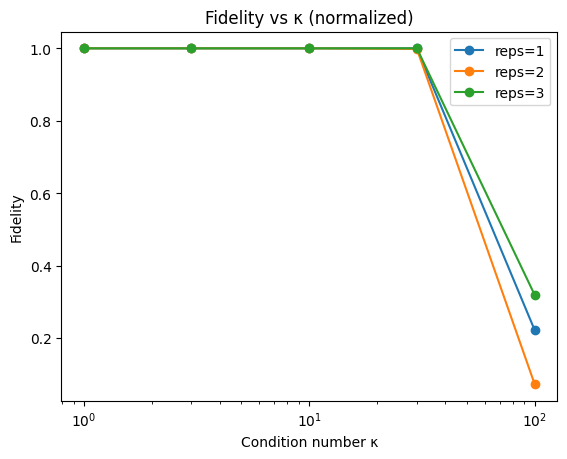

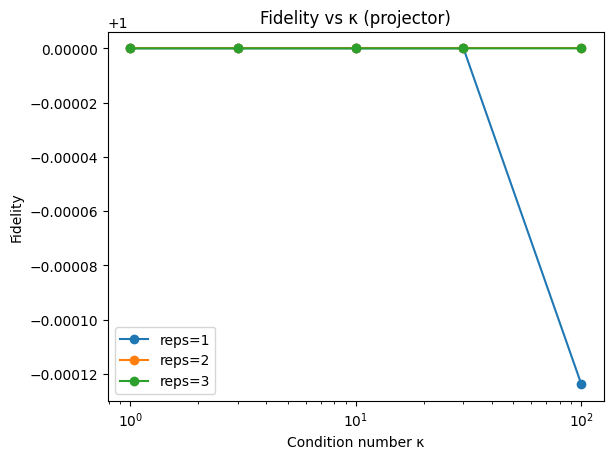

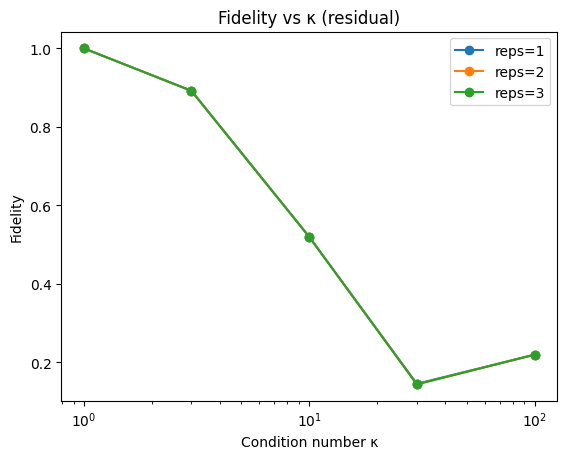

In [44]:
plot_metric(df, "fidelity", "Fidelity", "Fidelity")

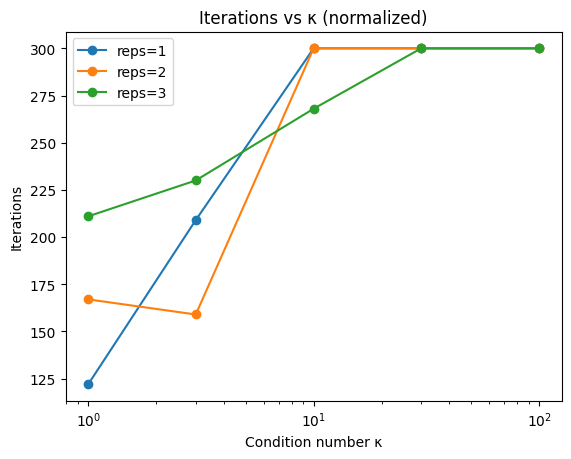

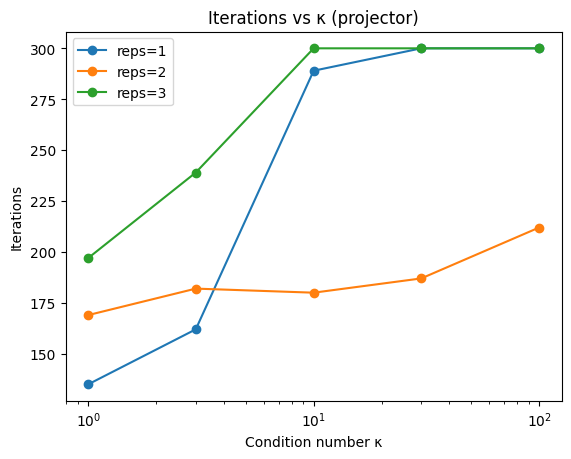

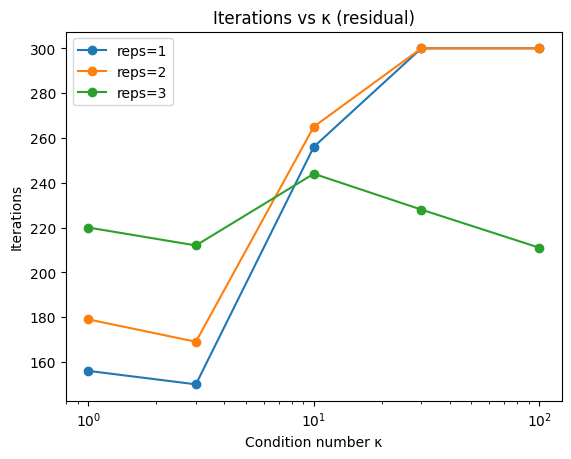

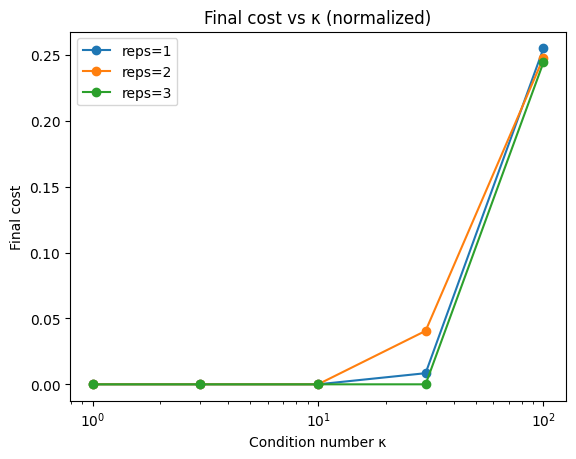

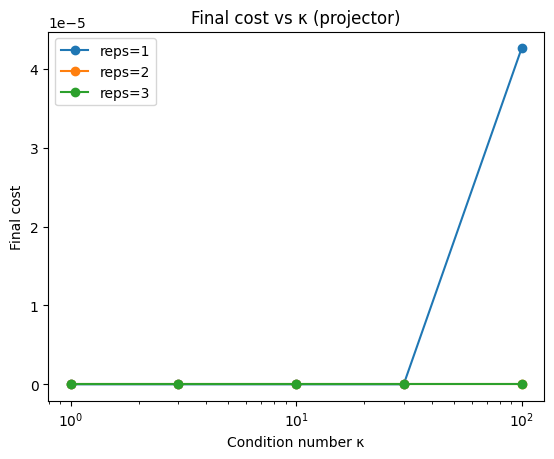

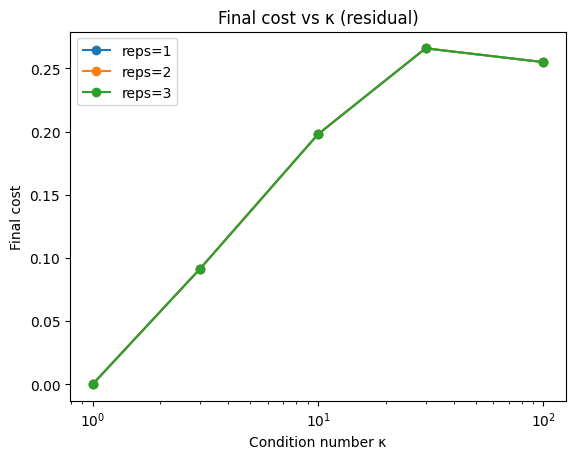

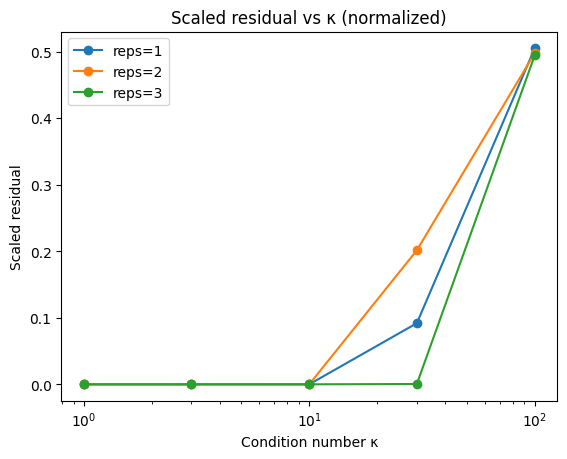

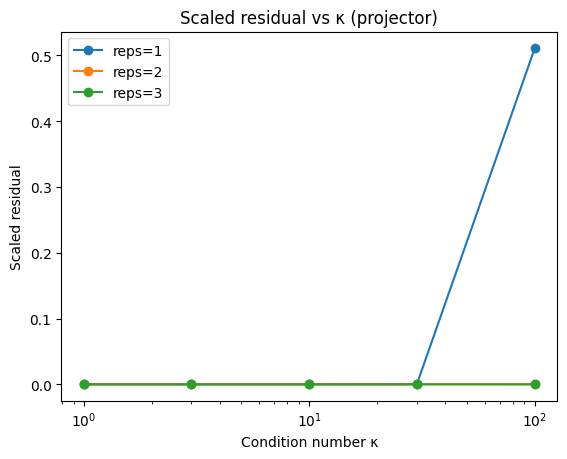

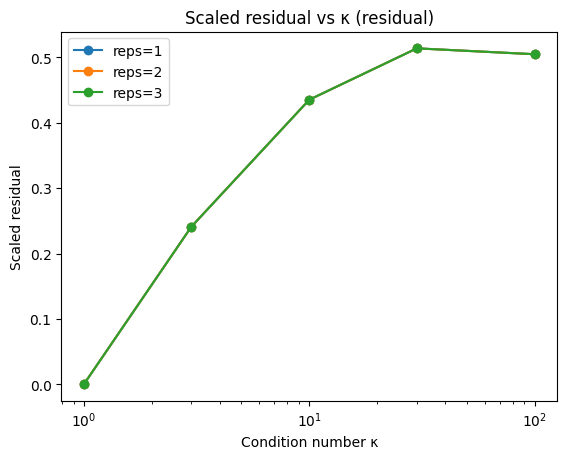

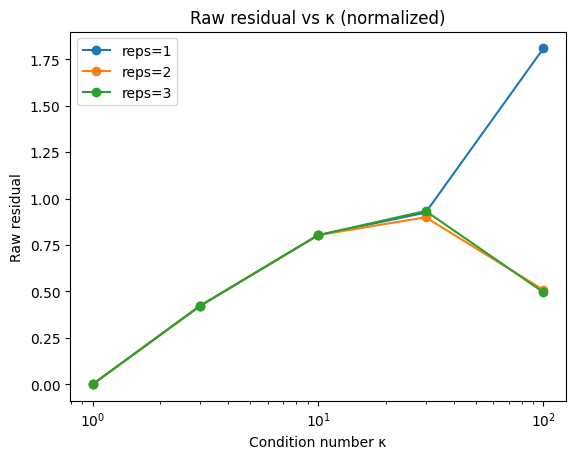

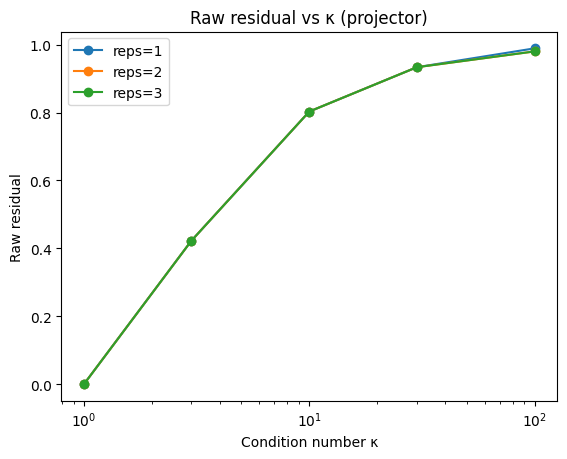

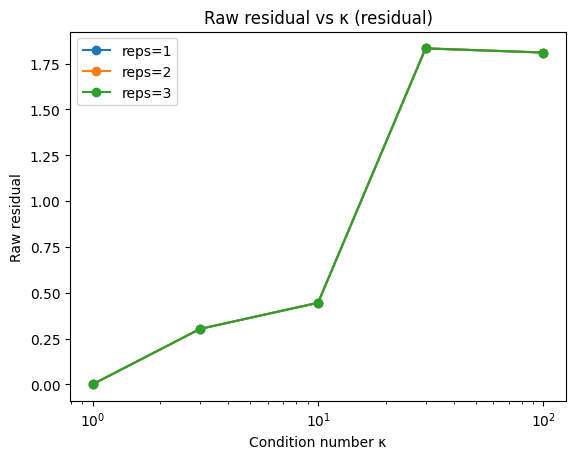

In [43]:
plot_metric(df, "iters", "Iterations", "Iterations")
plot_metric(df, "final_cost", "Final cost", "Final cost")
plot_metric(df, "scaled_residual", "Scaled residual", "Scaled residual")
plot_metric(df, "raw_residual", "Raw residual", "Raw residual")

The fidelity plots show that the projector cost is robust for this benchmark, especially for deeper ansatz choices. The normalized cost performs well for moderate condition numbers but can degrade at large $\kappa$. The residual cost performs significantly worse as $\kappa$ increases, indicating that it is more sensitive to conditioning and normalization issues.

The optimizer often requires more function evaluations as $\kappa$ increases. In several cases, the optimizer reaches the maximum iteration limit of 300. This suggests that poorly conditioned systems produce more difficult optimization landscapes.

The final cost generally increases for larger $\kappa$, especially for the normalized and residual costs. However, the final cost should be interpreted together with fidelity and scaled residual, because different cost functions measure different quantities.

The scaled residual is particularly important for VQLS because the quantum state is normalized. A small scaled residual indicates that the direction of the VQLS solution is correct after accounting for an overall scale.

The raw residual can remain large even when the fidelity is high. This happens because the VQLS output is a normalized state, while the true linear-system solution may require a different magnitude. Therefore, raw residual alone can be misleading for VQLS state outputs.

## Comparing Cost Functions at Fixed Ansatz Depth

We now fix the ansatz depth and compare different cost functions directly.

This helps answer the question:

> For a given circuit depth, which cost function is most robust as the condition number increases?

This comparison is useful because ansatz depth and cost-function choice are coupled: a cost function that performs well at shallow depth may behave differently at larger depth.

In [45]:
def plot_metric_fixed_reps(df, metric, ylabel, title_prefix):
    for reps, df_rep in df.groupby("reps"):
        plt.figure()

        for cost_type, sub in df_rep.groupby("cost_type"):
            sub = sub.sort_values("kappa")
            plt.plot(sub["kappa"], sub[metric], marker="o", label=cost_type)

        plt.xscale("log")
        plt.xlabel("Condition number κ")
        plt.ylabel(ylabel)
        plt.title(f"{title_prefix} vs κ (reps={reps})")
        plt.legend()

        plt.savefig(f"{metric}_vs_kappa_reps_{reps}.png", dpi=300, bbox_inches="tight")
        plt.show()

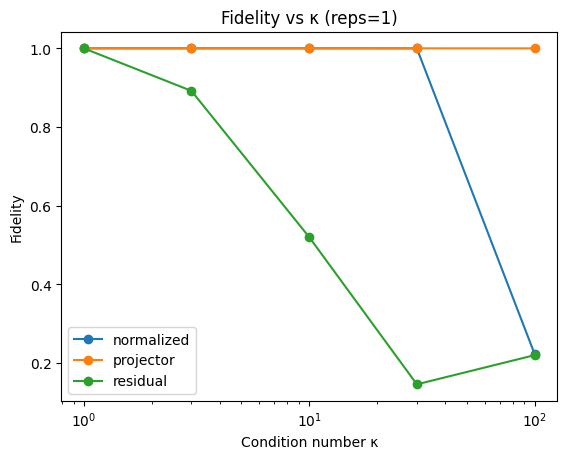

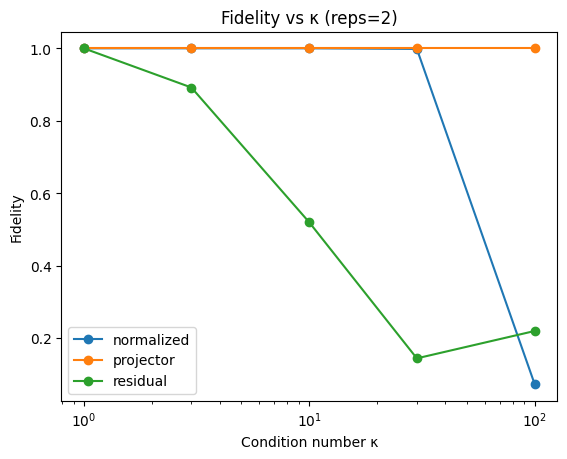

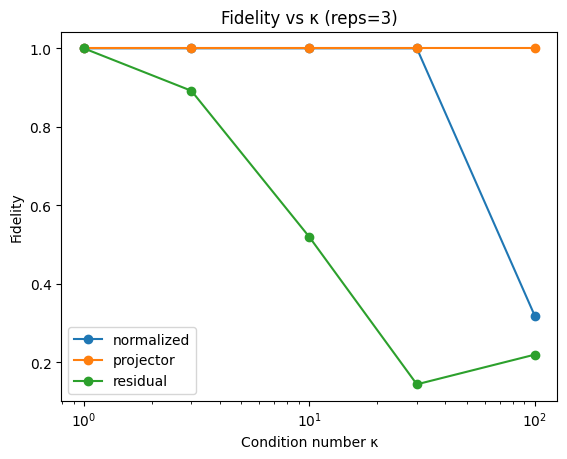

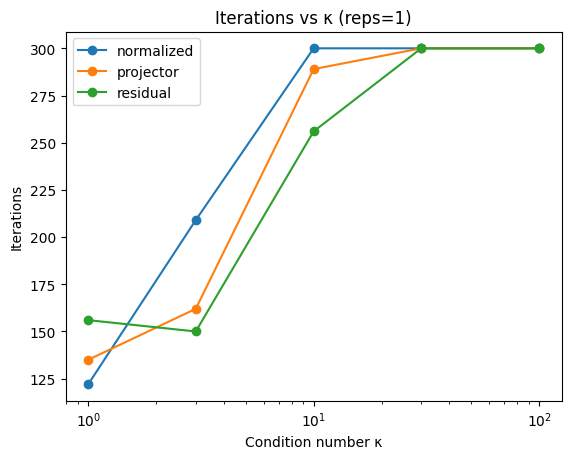

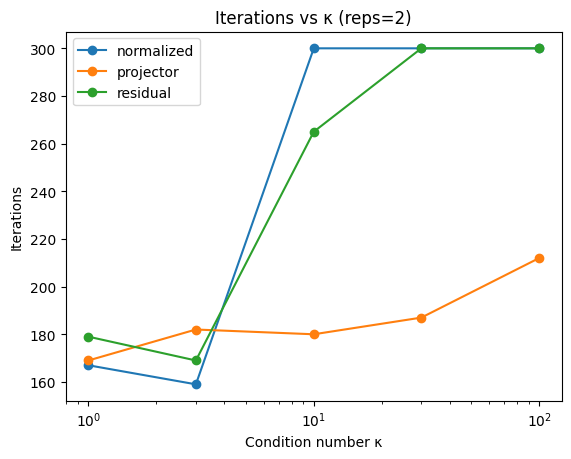

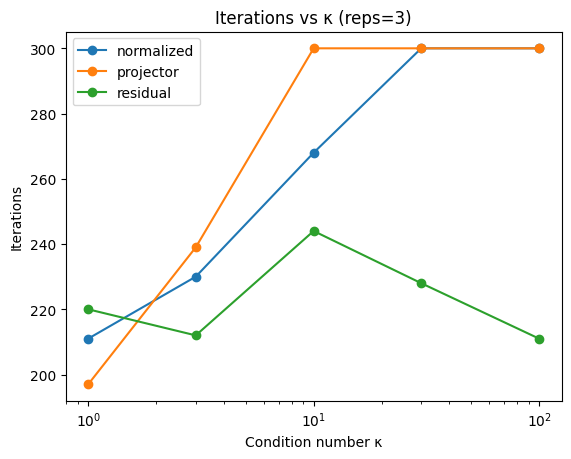

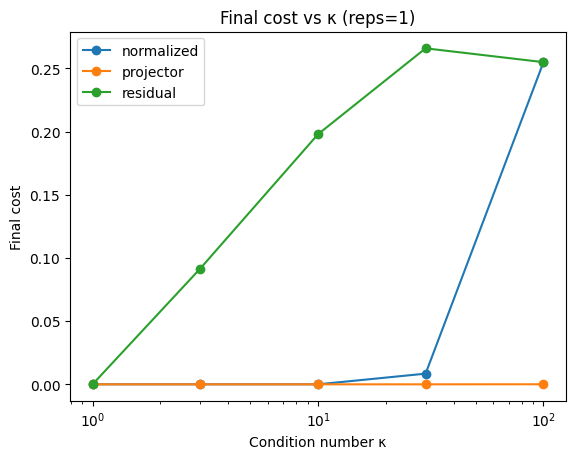

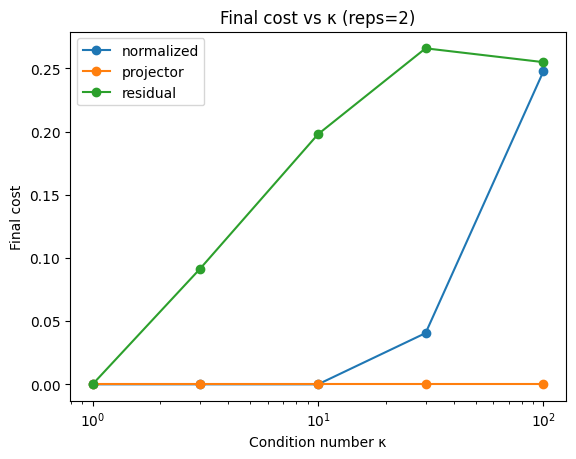

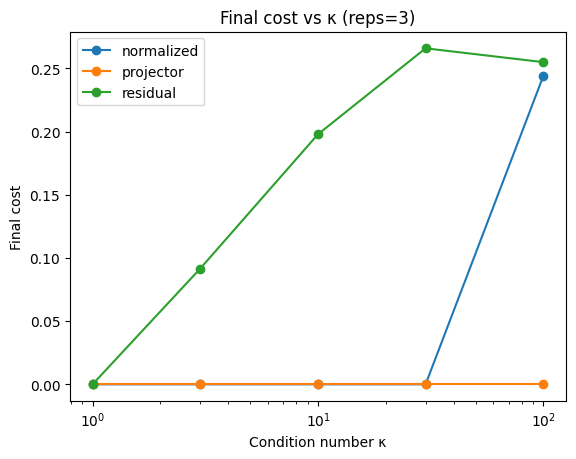

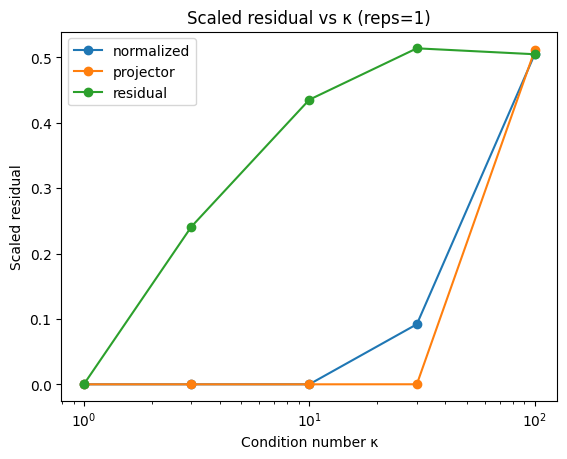

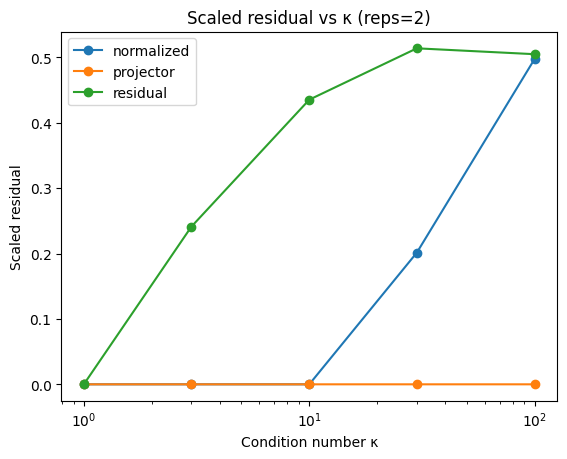

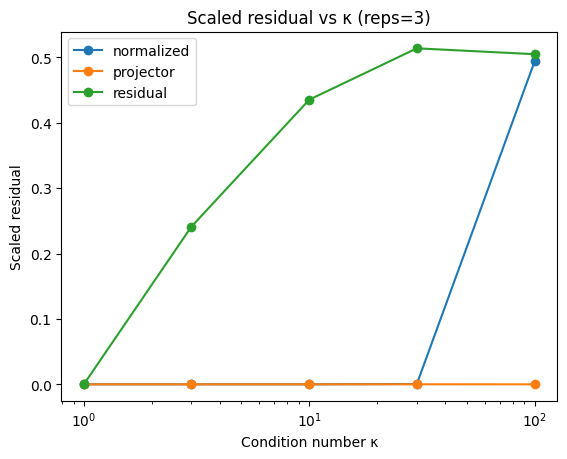

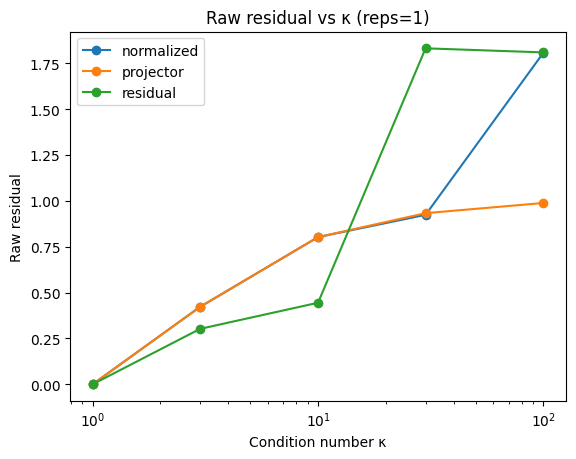

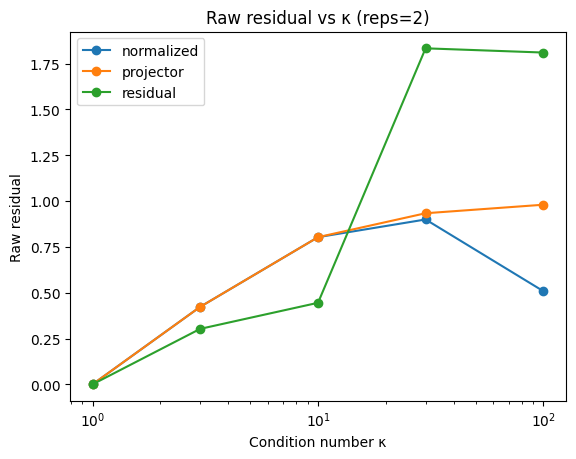

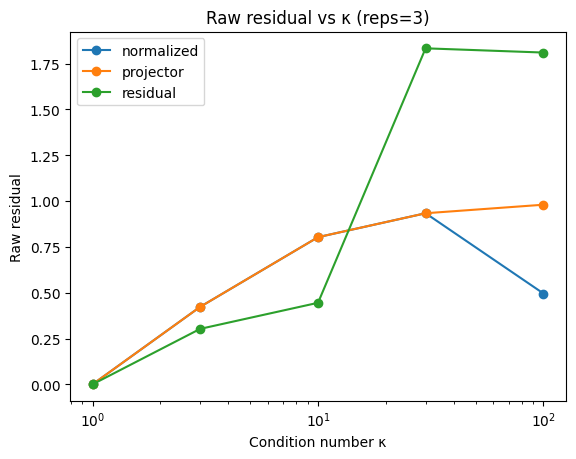

In [46]:
plot_metric_fixed_reps(df, "fidelity", "Fidelity", "Fidelity")
plot_metric_fixed_reps(df, "iters", "Iterations", "Iterations")
plot_metric_fixed_reps(df, "final_cost", "Final cost", "Final cost")
plot_metric_fixed_reps(df, "scaled_residual", "Scaled residual", "Scaled residual")
plot_metric_fixed_reps(df, "raw_residual", "Raw residual", "Raw residual")

At fixed ansatz depth, the projector cost generally gives the most stable fidelity across condition numbers. The residual cost is the least robust in this benchmark. The normalized cost performs well in some regimes but can degrade for large $\kappa$, especially when the optimizer reaches its iteration limit.

## Discussion

This noiseless benchmark isolates several limitations of VQLS.

First, increasing the condition number generally makes the optimization harder. This appears through larger final costs, larger residuals, lower fidelity in some cases, and more optimizer function evaluations.

Second, the choice of cost function matters. The projector cost performs well in this benchmark because it focuses on the alignment between $A|x\rangle$ and $|b\rangle$. The normalized cost also accounts for the scale of $A|x\rangle$, but can become harder to optimize for larger condition numbers. The residual cost directly penalizes $|A|x\rangle-|b\rangle|$, but this can be less suitable when the ansatz state is normalized and the true solution has a nontrivial overall scale.

Third, ansatz depth does not guarantee monotonic improvement. Increasing `reps` improves expressibility, but also increases the number of parameters and can make the optimization landscape more difficult.

Fourth, the raw residual and fidelity can tell different stories. A state can have high fidelity with the normalized classical solution while still having a large raw residual because the VQLS output is normalized. This is why the scaled residual is a useful diagnostic.

Finally, even without noise, VQLS performance is limited by conditioning, cost-function design, ansatz expressibility, and classical optimization. These issues become even more important when VQLS is used repeatedly inside time-stepping algorithms for differential equations.

## Summary

In this notebook, we studied VQLS limitations in a noiseless two-qubit benchmark problem with tunable condition number.

The main findings are:

1. Poor conditioning makes VQLS harder, even without hardware noise.
2. The projector cost is robust for this benchmark.
3. The residual cost performs poorly for larger $\kappa$, partly because the VQLS output is normalized.
4. The normalized cost performs well in some regimes but can degrade for large $\kappa$.
5. Increasing ansatz depth does not always guarantee better results.
6. The scaled residual is more informative than the raw residual for normalized quantum-state outputs.
7. Pauli-term counts provide a simple proxy for measurement overhead.

This benchmark provides a controlled way to understand VQLS before applying it to differential-equation solvers, where these limitations can accumulate over many time steps.